# Day 6 — CNN Basics (D2L-Aligned)

> **Main route:** follow D2L Chapter 6 in order, then read only the core idea of ResNet from D2L §7.6.

## Today’s D2L route

1. D2L §6.1 — 从全连接层到卷积
2. D2L §6.2 — 图像卷积
3. D2L §6.3 — 填充和步幅
4. D2L §6.4 — 多输入多输出通道
5. D2L §6.5 — 汇聚层
6. D2L §6.6 — 卷积神经网络（LeNet）
7. D2L §7.6 — 残差网络（ResNet），**只看 residual connection 核心思想**
8. Day 6 Summary

## Learning priority

### Must understand
- Why MLP is not ideal for images
- Locality
- Translation invariance / weight sharing intuition
- Convolution
- Kernel / filter
- Feature map
- Stride
- Padding
- Input / output channels
- Pooling
- Shape tracking
- Basic LeNet-style CNN

### High-level only
- Residual connection
- Why ResNet helps deep networks
- Why residual connections matter later in Transformers

### Skip for now
- AlexNet details
- VGG details
- NiN
- GoogLeNet / Inception
- DenseNet
- ResNet-18/34/50 exact architecture tables


# 0. Optional prerequisite — D2L §4.8 数值稳定性和模型初始化

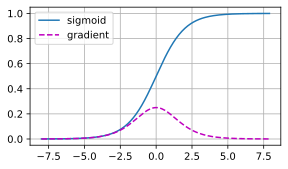

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

d2l.plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))

In [2]:
M = torch.normal(0, 1, size=(4,4))
print('一个矩阵 \n',M)
for i in range(100):
    M = torch.mm(M,torch.normal(0, 1, size=(4, 4)))

print('乘以100个矩阵后\n', M)

一个矩阵 
 tensor([[-0.0201,  0.1319, -0.0667,  0.0534],
        [-0.2048,  0.3572,  0.6267, -1.1263],
        [-1.3978,  0.7772, -0.5618,  0.5150],
        [-0.4434,  0.2273,  0.0768,  0.7979]])
乘以100个矩阵后
 tensor([[-4.9881e+22,  1.5217e+23, -1.1686e+23,  2.2747e+23],
        [ 4.3916e+23, -1.3398e+24,  1.0289e+24, -2.0027e+24],
        [-4.4922e+23,  1.3704e+24, -1.0524e+24,  2.0485e+24],
        [-3.5537e+23,  1.0841e+24, -8.3257e+23,  1.6206e+24]])


# 1. D2L §6.1 — 从全连接层到卷积

## Core idea

Images are not just flat vectors.

An image tensor keeps spatial structure:

`[batch, channels, height, width]`

A fully-connected layer usually flattens:

`[B, C, H, W] -> [B, C*H*W]`

CNN introduces two key structural assumptions:

- **locality**: nearby pixels matter together
- **parameter sharing**: the same local detector can be reused at different positions

## Must answer

- Why does flattening lose explicit spatial structure?
- Why does parameter sharing reduce parameter count?
- Why can the same local pattern appear at different image positions?


# 2. D2L §6.2 — 图像卷积

In [3]:
import torch
from torch import nn
from d2l import torch as d2l

def corr2d(X,K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0]-h+1),(X.shape[1]-w+1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i,j] = (X[i:i+h,j:j+w] * K).sum()
    return Y

In [4]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [5]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super.__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self,x):
        return corr2d(x, self.weight) + self.bias

In [6]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [7]:
K = torch.tensor([[1.0, -1.0]])

In [8]:
Y = corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [9]:
corr2d(X.t(), K)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [10]:
conv2d = nn.Conv2d(1,1, kernel_size=(1, 2), bias=False)

X = X.reshape(1, 1, 6, 8)
Y = Y.reshape(1, 1, 6, 7)
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
         print(f'epoch {i+1}, loss {l.sum():.3f}')

epoch 2, loss 10.760
epoch 4, loss 3.564
epoch 6, loss 1.318
epoch 8, loss 0.516
epoch 10, loss 0.207


# 3. D2L §6.3 — 填充和步幅

For one spatial dimension:

`output = floor((input + 2*padding - kernel_size) / stride) + 1`

## Padding

Padding adds extra values around the border.

Why:
- preserve border information
- control output size
- often keep spatial size unchanged

Common pattern:

`kernel_size=3, stride=1, padding=1`

keeps H/W unchanged.

## Stride

Stride controls how far the kernel moves each step.

Larger stride:
- fewer positions
- smaller output
- lower computation


In [11]:
import torch
from torch import nn

def comp_conv2d(conv2d, X):
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    return Y.reshape(Y.shape[2:])

conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

In [19]:
conv2d = nn.Conv2d(1, 1, kernel_size=(5, 3), padding=(2, 1))
X = torch.rand(size=(8,8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

In [20]:
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

In [21]:
conv2d = nn.Conv2d(1, 1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])

# 4. D2L §6.4 — 多输入多输出通道

CNN tensors usually use:

`[B, C, H, W]`

## Input channels

Examples:
- grayscale image: 1 channel
- RGB image: 3 channels
- deeper CNN layers: many learned channels

## Output channels

`out_channels` = number of learned output feature maps.

Example:

`Conv2d(1, 16, kernel_size=3)`

means:
- input has 1 channel
- layer learns 16 output channels
- output contains 16 feature maps

Each output channel combines information from **all input channels**.


In [22]:
def corr2d_multi_in(X,K):
    return sum(d2l.corr2d(x,k) for x,k in zip(X,K))

In [23]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

In [37]:
def corr2d_multi_in_out(X,K):
    return torch.stack([corr2d_multi_in(X,k) for k in K],0)

In [39]:
K = torch.tensor([
    [
        [0.,1.],
        [2.,3.]
    ],
    [
        [1.,2.],
        [3.,4.]
    ]
])

In [40]:
K = torch.stack((K, K + 1, K + 2), 0)
K.shape

torch.Size([3, 2, 2, 2])

In [41]:
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

In [48]:
def corr2d_multi_in_out_1x1(X,K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i,h*w))
    K = K.reshape((c_o,c_i))
    Y = torch.matmul(K,X)
    return Y.reshape((c_o, h, w))

In [49]:
X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))

Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6

# 5. D2L §6.5 — 汇聚层

In [52]:
import torch
from torch import nn
from d2l import torch as d2l

def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

In [53]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

In [54]:
pool2d(X, (2, 2), 'avg')

tensor([[2., 3.],
        [5., 6.]])

In [55]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

In [56]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [57]:
X = torch.cat((X, X + 1), 1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [58]:
X = torch.cat((X, X + 1), 1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]],

         [[ 2.,  3.,  4.,  5.],
          [ 6.,  7.,  8.,  9.],
          [10., 11., 12., 13.],
          [14., 15., 16., 17.]]]])

# 6. D2L §6.6 — 卷积神经网络（LeNet）

In [63]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

In [64]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [65]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [66]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [67]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.465, train acc 0.824, test acc 0.829
7654.8 examples/sec on cpu


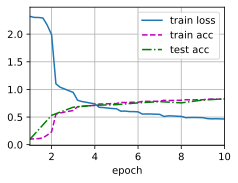

In [68]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

# 7. Fashion-MNIST — CNN Training

Use the same training pipeline you already know:

`Dataset -> DataLoader -> Model -> Loss -> Backward -> Optimizer -> Evaluation`

Do not treat CNN training as a new training framework.

The **training loop is the same**.

Only the model architecture changed.


In [15]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_iter = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=256, shuffle=False)

net = SimpleLeNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)

print("train samples:", len(train_dataset))
print("test samples :", len(test_dataset))


train samples: 60000
test samples : 10000


In [16]:
def evaluate_accuracy(net, data_iter):
    net.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in data_iter:
            logits = net(X)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total


num_epochs = 5

for epoch in range(num_epochs):
    net.train()

    total_loss = 0.0
    total = 0
    correct = 0

    for X, y in train_iter:
        optimizer.zero_grad()

        logits = net(X)
        loss = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.shape[0]
        total += y.numel()
        correct += (logits.argmax(dim=1) == y).sum().item()

    train_loss = total_loss / total
    train_acc = correct / total
    test_acc = evaluate_accuracy(net, test_iter)

    print(
        f"epoch {epoch+1}: "
        f"loss={train_loss:.4f}, "
        f"train acc={train_acc:.4f}, "
        f"test acc={test_acc:.4f}"
    )


epoch 1: loss=1.7179, train acc=0.3786, test acc=0.5897
epoch 2: loss=0.9060, train acc=0.6479, test acc=0.6964
epoch 3: loss=0.7497, train acc=0.7176, test acc=0.7254
epoch 4: loss=0.6685, train acc=0.7429, test acc=0.7457
epoch 5: loss=0.6139, train acc=0.7602, test acc=0.7624


# 8. D2L §7.5 — BatchNorm

In [69]:
def batch_norm(x, gamma, beta):
    mean = x.mean(dim=0)
    var = ((x-mean)**2).mean(dim=0)

    x_hat = (x - mean) / torch.sqrt(var + 1e-5)
    
    return gamma*x_hat + beta

# 9. D2L §7.6 — ResNet（只看核心思想）

Do **not** study all modern CNN architectures today.

Jump directly to the key idea of ResNet:

`y = F(x) + x`

This is a **residual / skip connection**.

In [87]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1)

        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None

        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [88]:
blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

In [89]:
blk = Residual(3,6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

In [90]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

In [91]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

In [92]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block = True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [93]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

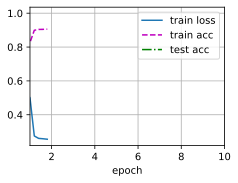

In [ ]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

# 10. Day 6 Summary

## I should be able to explain

- **Why CNN is more suitable for images than a plain MLP:**
  
  CNN preserves the spatial structure of images through local connections and parameter sharing, while MLP requires flattening images and ignores spatial relationships.

- **What locality means:**

  Convolution only looks at a local region of the image instead of the whole image, allowing the model to capture local patterns such as edges and textures.

- **What parameter sharing means:**

  The same kernel/filter is reused across different spatial locations, reducing parameters and allowing the same feature detector to recognize patterns in different positions.

- **What convolution does:**

  A convolution operation applies learnable filters over the input feature map to extract useful features.

- **What a kernel/filter is:**

  A learnable weight matrix that slides over the input and detects specific patterns.

- **What a feature map is:**

  The output of applying a filter, representing where a certain feature appears in the input.

- **What stride controls:**

  Stride controls the step size of the convolution movement and determines the output spatial size.

- **What padding controls:**

  Padding adds extra pixels around the input to preserve edge information and control output dimensions.

- **What input/output channels mean:**

  Input channels represent the number of input feature maps, while output channels represent the number of filters and generated feature maps.

- **What pooling does:**

  Pooling reduces spatial dimensions, decreases computation, increases receptive field, and provides some translation invariance.

- **How tensor shapes change through LeNet:**

  Image:
  \[
  C\times H\times W
  \]

  → convolution changes channels and extracts features  
  → pooling reduces spatial size  
  → flatten converts feature maps into vectors  
  → fully connected layers perform classification.

- **Why CNN training still uses the same training loop:**

  CNN is still a neural network. Forward propagation computes predictions, loss is calculated, backpropagation computes gradients, and optimizers update parameters.

- **What a residual connection is:**

  Residual connection adds the original input directly to the transformed output:

  \[
  Y=F(X)+X
  \]

  It allows information and gradients to flow more easily through deep networks.

- **Why ResNet matters beyond computer vision:**

  ResNet solves the optimization problem of very deep networks by introducing residual learning.  
  The same residual idea is later used in Transformer architectures:

  \[
  x+Attention(x)
  \]

  \[
  x+FFN(x)
  \]


---

## D2L Route Completed

`§6.1 -> §6.2 -> §6.3 -> §6.4 -> §6.5 -> §6.6 -> §7.6(core only)`


---

## One-sentence takeaway

CNN extracts spatial features through convolution, locality, and parameter sharing, while ResNet solves deep network optimization by introducing residual connections:

\[
y=F(x)+x
\]

This residual design later becomes a fundamental component of Transformer architectures.